In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


In [83]:
df=pd.read_csv("/content/Student Social Media And Mental Health Impact.csv")

In [84]:
df.shape

(5000, 13)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [86]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [87]:
df.duplicated().sum()

np.int64(2)

In [88]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

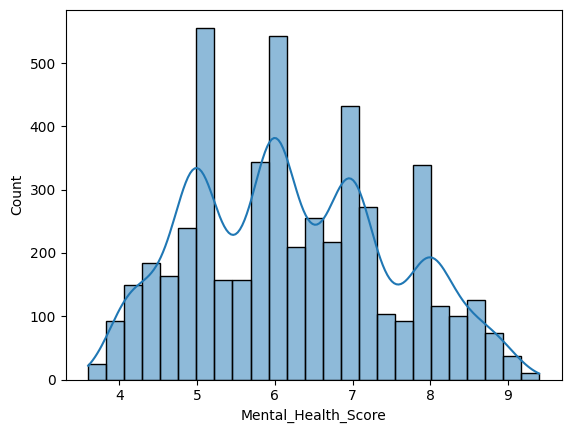

In [89]:
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

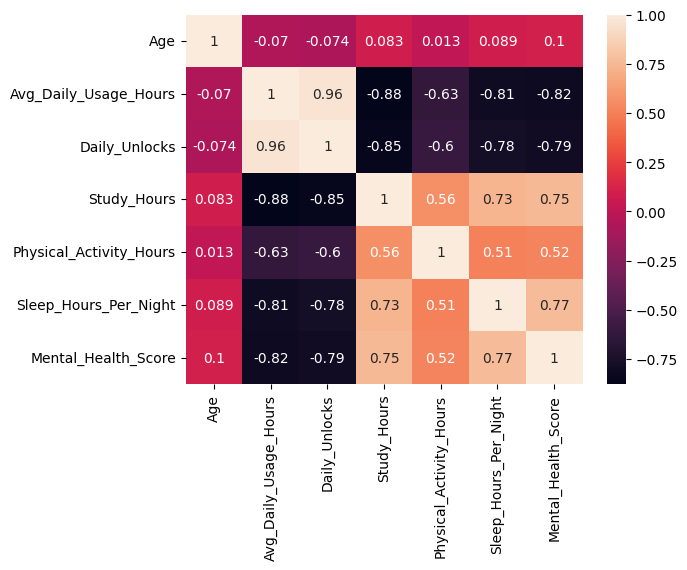

In [90]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [91]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

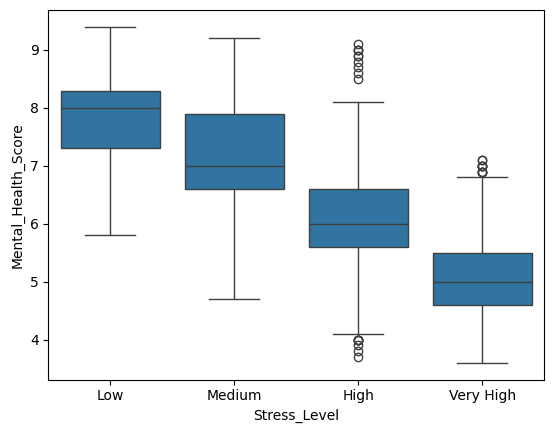

In [92]:
order=['Low','Medium','High','Very High']

sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df,order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

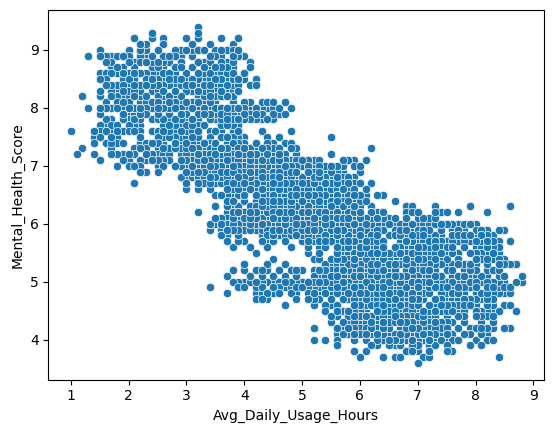

In [93]:
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

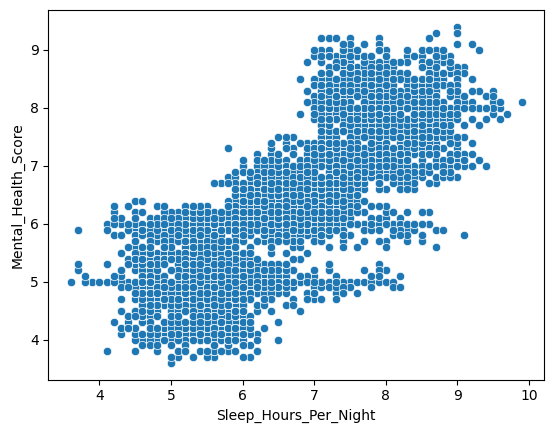

In [94]:
sns.scatterplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data=df)


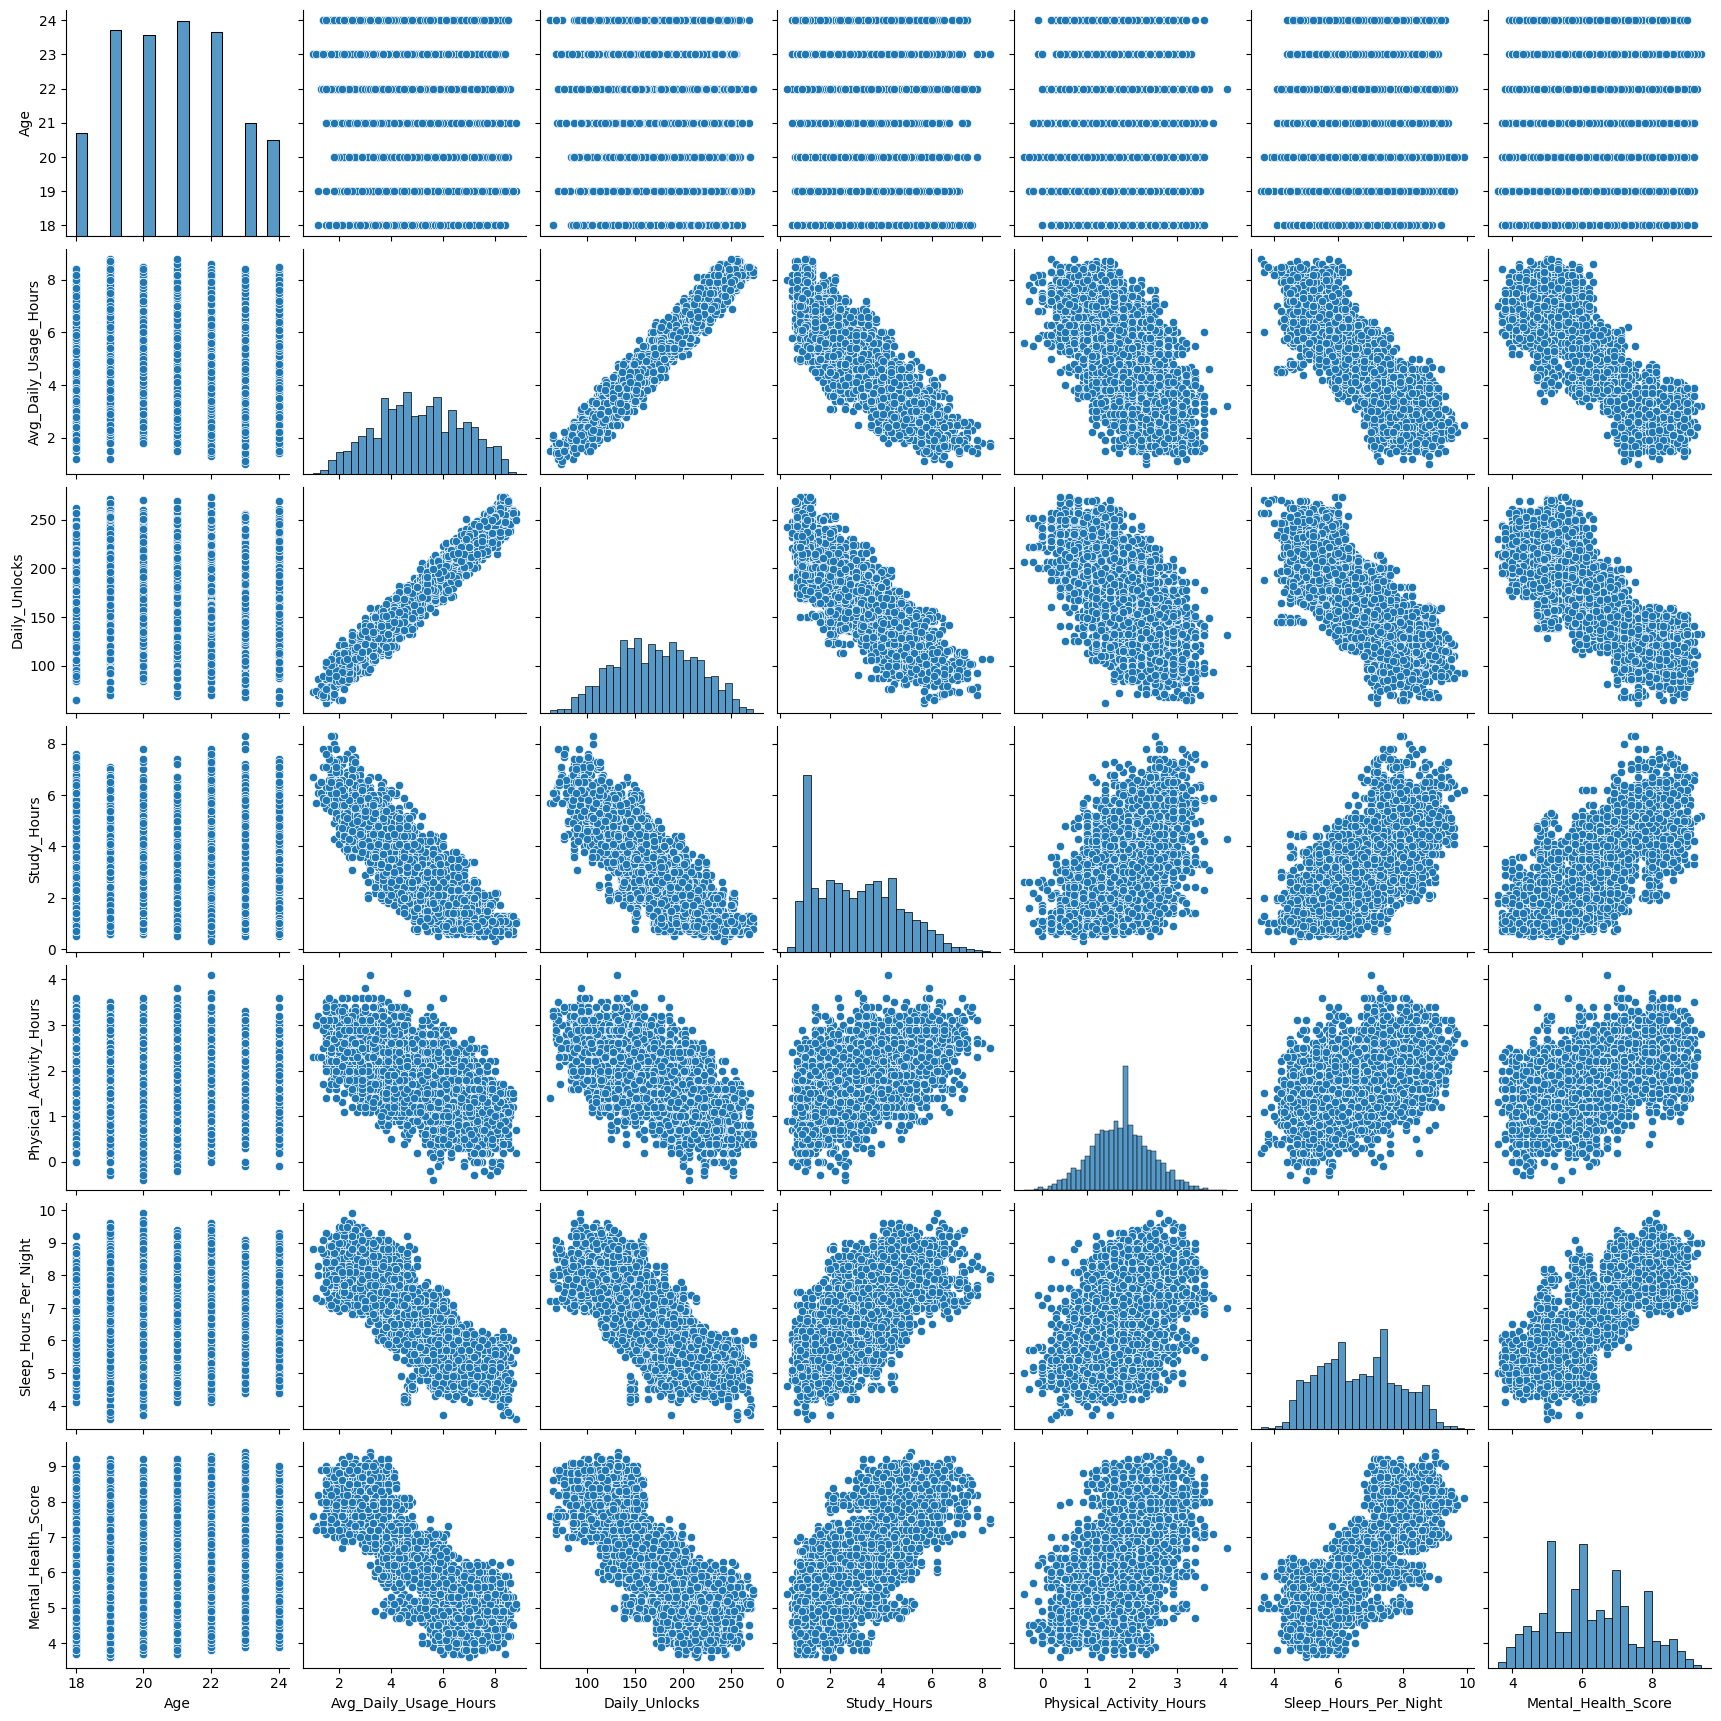

In [95]:
sns.pairplot(data=df)

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

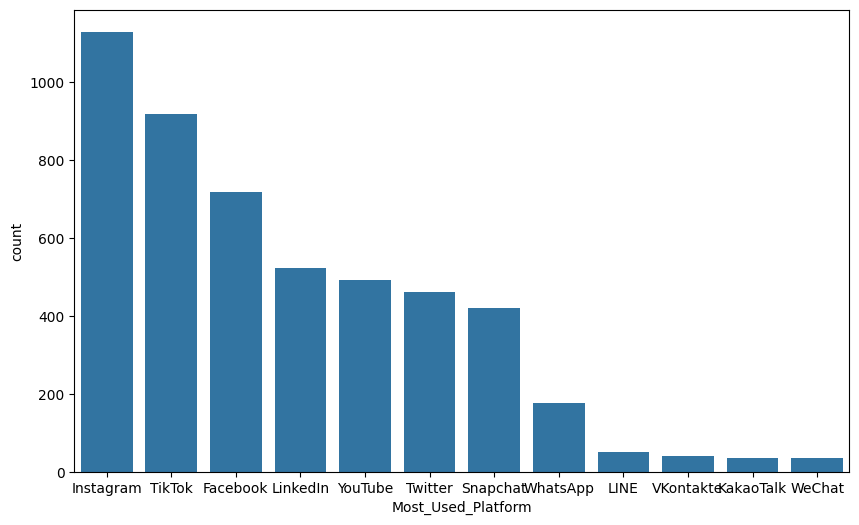

In [96]:
platform_counts=df["Most_Used_Platform"].value_counts().index
plt.figure(figsize=(10,6))
sns.countplot(x='Most_Used_Platform',data=df,order=platform_counts)

In [97]:
num_features=df.select_dtypes(include='number')
Q1= num_features.quantile(0.25)
Q3=num_features.quantile(0.75)
IQR=Q3-Q1

lower_bound= Q1 - 1.5 * IQR
upper_bound= Q3 + 1.5 * IQR

outliers=(num_features<lower_bound) | (num_features > upper_bound)

print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [98]:
df=df.drop_duplicates()

df['Physical_Activity_Hours']= df['Physical_Activity_Hours'].clip(lower=0)

/tmp/ipykernel_1528/3773461367.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Physical_Activity_Hours']= df['Physical_Activity_Hours'].clip(lower=0)


In [99]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [100]:
num_cols=df.select_dtypes(include='number')
num_cols.skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [101]:
top_countries=df['Country'].value_counts().index[:10].tolist()

In [102]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [103]:
df['Group_Country']=df['Country'].apply(group_countries)

/tmp/ipykernel_1528/3359666846.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Group_Country']=df['Country'].apply(group_countries)


In [104]:
df['Group_Country'].value_counts()

,count
Group_Country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [105]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Group_Country'],
      dtype='object')

In [113]:
from sklearn.model_selection import train_test_split
skews_cols=['Study_Hours']

other_numeric_cols=['Age','Avg_Daily_Usage_Hours', 'Daily_Unlocks','Physical_Activity_Hours', 'Sleep_Hours_Per_Night']

ordinal_col=['Stress_Level']

normal_cols= ['Gender','Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Group_Country']


feature_cols = skews_cols + other_numeric_cols + ordinal_col + normal_cols

X=df[feature_cols]
y=df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [114]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer ,StandardScaler, OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer

skew_pipeline=Pipeline(steps=[
    ('log_transform',FunctionTransformer(np.log1p)),
     ('scale',StandardScaler())
])


plain_numerical_pipeline=Pipeline(steps=[
    (
      'scale',StandardScaler()
    )
])


ordinal_pipeline=Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
    ])


nominal_pipeline=Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor= ColumnTransformer(transformers=[
    ('Skewes_Pipeline',skew_pipeline,skews_cols),
    ('Nomal_Cols_Pipeline',nominal_pipeline,normal_cols),
    ('Plain_Numeric_Pipeline',plain_numerical_pipeline ,other_numeric_cols),
    ('Ordinal_Pipeline',ordinal_pipeline,ordinal_col)
])

In [120]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

lr_pipeline.fit(X_train,y_train)
lr_preds=lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing=r2_score(y_test,lr_preds)
lr_r2_training=r2_score(y_train,lr_preds_train)
lr_mae=mean_absolute_error(y_test,lr_preds)


print(f'Accuracy of training {lr_r2_training}')
print(f'Accuracy of testing {lr_r2_testing}')
print(f'MAE {lr_mae}')

Accuracy of training 0.7236771199387539
Accuracy of testing 0.739794461743302
MAE 0.5361775634720183


In [123]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('random forest',RandomForestRegressor())

])
rf_pipeline.fit(X_train,y_train)
rf_pipeline.fit(X_train,y_train)
rf_preds=rf_pipeline.predict(X_test)
rf_preds_train = rf_pipeline.predict(X_train)

rf_r2_testing=r2_score(y_test,rf_preds)
rf_r2_training=r2_score(y_train,rf_preds_train)
rf_mae=mean_absolute_error(y_test,rf_preds)

print(f'Accuracy of training {rf_r2_training}')
print(f'Accuracy of testing {rf_r2_testing}')
print(f'MAE {rf_mae}')

Accuracy of training 0.981000856457255
Accuracy of testing 0.8760691459735384
MAE 0.3497090666666668


In [131]:
from sklearn.model_selection import RandomizedSearchCV


param_grid={
    'random forest__n_estimators'   :  [100,200,300],
    'random forest__max_depth'     :  [5,10,15],
    'random forest__min_samples_split':[2,5,10],
    'random forest__min_samples_leaf':[1,2,4]

    }

random_search= RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='r2',
    n_jobs=1,
    random_state=42
)


random_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewes_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Nomal_Cols_Pipeline',
                                                                               Pipeline(steps=[('encode',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Gender',
                                                                                'Academic_L...
                                                                                                OrdinalEncoder(categories=[['Low',
                                                                                                                            'Medium',
                                                                                                                            'High',
                                                                                                                            'Very '
                                                                                                                            'High']]))]),
                                                                               ['Stress_Level'])])),
                                             ('random forest',
                                              RandomForestRegressor())]),
                   n_iter=15, n_jobs=1,
                   param_distributions={'random forest__max_depth': [5, 10, 15],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [132]:
random_search.best_params_

{'random forest__n_estimators': 300,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [135]:
rf_best_pipeline=random_search.best_estimator_
rf_best_preds=rf_best_pipeline.predict(X_test)

print(f"r2 score {r2_score(y_test,rf_best_preds)}")
print(f'mae {mean_absolute_error(y_test,rf_best_preds)}')

r2 score 0.8650139385637657
mae 0.36735040298983795


In [136]:
from sklearn.metrics import mean_squared_error


lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)


                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest (default)  0.876069     0.981001  0.349709  0.466550
2    Random Forest (tuned)  0.865014     0.954760  0.367350  0.486915


In [137]:
import joblib
joblib.dump(rf_pipeline,'Mental_Health_Model.pkl')


['Mental_Health_Model.pkl']